In [646]:
import pandas as pd
import time 
import math as math
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBRegressor, XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [ ]:
data_path = "gaming_addiction.csv"

df = pd.read_csv(data_path)

df.head(10)


,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


In [648]:
# Dropping user_id we dont use it
df = df.drop(['user_id'], axis=1)

In [649]:

# print(df.columns.to_list())
# print(df.dtypes)
# print(df.shape)

print("Reading data null : ", df.isnull().sum())




Reading data null :  age                             0
gender                          0
country                         0
occupation                      0
income_level                    0
years_gaming                    0
preferred_genre                 0
platform                        0
device_type                     0
rank_tier                       0
daily_playtime_hours            0
weekly_play_sessions            0
late_night_sessions_hours       0
weekend_playtime_hours          0
consecutive_hours_max           0
multiplayer_ratio               0
toxic_chat_reports              0
rage_quit_frequency             0
in_game_purchases               0
monthly_spending_usd            0
lootbox_openings                0
subscription_status            82
stress_score                    0
loneliness_score                0
dopamine_dependency_index       0
self_control_score              0
impulsiveness_score             0
anxiety_level                   0
depression_indicator       

subscription_status         82
depression_indicator        11
gpa_or_performance_score    10
addiction_severity          16
dtype: int64


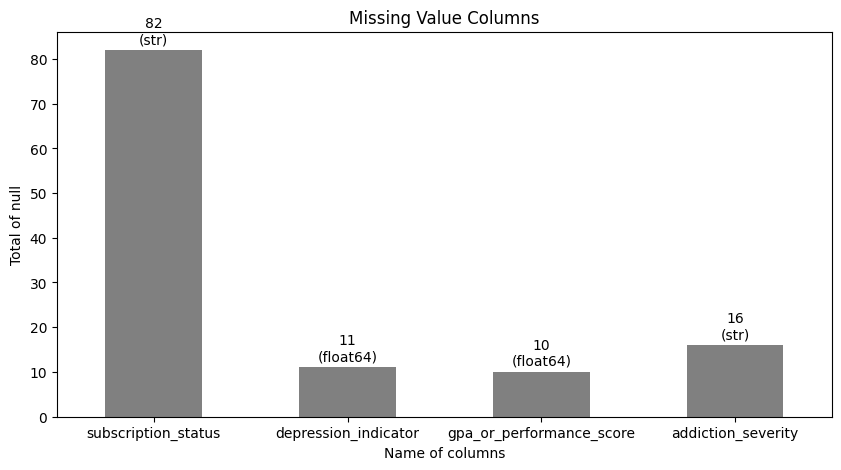

In [650]:
# Searching for null fields

missing_value = df.isnull().sum()[df.isnull().sum() > 0]

missing_types = df[missing_value.index].dtypes

print(df.isnull().sum()[df.isnull().sum() > 0])

plt.figure(figsize=(10,5))

ax = missing_value.plot.bar(color='gray')

for i, col in enumerate(missing_value.index):
    count = missing_value[col]
    dtype = missing_types[col]

    ax.text(i, count + (max(missing_value) * 0.01), f"{count}\n({dtype})", ha='center', va='bottom')

plt.title("Missing Value Columns")
plt.xlabel("Name of columns")
plt.ylabel("Total of null")
plt.xticks(rotation=0)
plt.show()

In [651]:
# Fixing missing value with SimpleImputer for numerical and catergory

dfe = df.copy()

# Numerical -> Median
num_imputer = SimpleImputer(strategy='median')
num_cols = ['depression_indicator', 'gpa_or_performance_score']
dfe[num_cols] = num_imputer.fit_transform(dfe[num_cols])

# Catergorial -> Modus 
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_cols = ['subscription_status', 'addiction_severity']
dfe[cat_cols] = cat_imputer.fit_transform(dfe[cat_cols])

print("Updating missing value : ", dfe.isnull().sum().max())



Updating missing value :  0


In [ ]:
# Preprocessing read the object and string data type 

print(dfe.select_dtypes(include=['object', 'str']))

print("Behavioral_cluster : ", dfe['behavioral_cluster'].unique())


     gender      country                occupation  income_level  \
0      Male        India                  Employed        Middle   
1      Male        India                  Employed  Lower-Middle   
2      Male       Brazil                  Employed        Middle   
3      Male  South Korea                  Employed  Upper-Middle   
4    Female        India                   Student        Middle   
..      ...          ...                       ...           ...   
245  Female        Japan  Streamer/Content Creator  Upper-Middle   
246    Male        India                   Student           Low   
247    Male          USA                   Student        Middle   
248    Male  South Korea                  Employed        Middle   
249    Male          USA                Unemployed        Middle   

    preferred_genre    platform   device_type rank_tier subscription_status  \
0           Sandbox          PC        Laptop      Gold             Premium   
1               RPG      

In [653]:
# Manual encoding using map 

cols = ['addiction_severity', 'income_level', 'subscription_status', 'rank_tier']

for i, col_name in enumerate(cols):
    # 3. Used the correct variable '{col_name}' and added a unique count method
    unique_count = df[col_name].unique()
    print(f"Index {i}: '{col_name}' has {unique_count} unique values")

dfe['income_level'] = dfe['income_level'].map({"Low" : 0, "Lower-Middle" : 1, "Middle" : 2, "Upper-Middle" : 3, "High" : 4})

dfe['addiction_severity'] = dfe['addiction_severity'].map({"Mild" : 0, "Moderate" : 1, "Severe" : 2})

dfe['subscription_status'] = dfe['subscription_status'].map({"Basic" : 0, "Premium" : 1, "Ultimate" : 2})

dfe['rank_tier'] = dfe['rank_tier'].map({"Unranked" : 0, "Bronze" : 1, "Silver" : 2, "Gold" : 3, "Platinum" : 4, "Diamond" : 5, "Master" : 6, "Grandmaster" : 7})

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_cols = ['gender', 'country', 'occupation', 'preferred_genre', 'platform', 'device_type', 'relationship_status', 'behavioral_cluster']

dfe = pd.get_dummies(dfe, columns=ohe_cols)

print(dfe.select_dtypes(include=['object', 'str']).columns.to_list)


Index 0: 'addiction_severity' has <StringArray>
['Mild', 'Moderate', nan, 'Severe']
Length: 4, dtype: str unique values
Index 1: 'income_level' has <StringArray>
['Middle', 'Lower-Middle', 'Upper-Middle', 'High', 'Low']
Length: 5, dtype: str unique values
Index 2: 'subscription_status' has <StringArray>
[nan, 'Premium', 'Ultimate', 'Basic']
Length: 4, dtype: str unique values
Index 3: 'rank_tier' has <StringArray>
[       'Gold',      'Bronze',      'Master',      'Silver',    'Unranked',
     'Diamond', 'Grandmaster',    'Platinum']
Length: 8, dtype: str unique values
<bound method IndexOpsMixin.tolist of Index([], dtype='str')>


In [654]:
dfe.dtypes

age                                         int64
income_level                                int64
years_gaming                                int64
rank_tier                                   int64
daily_playtime_hours                      float64
                                           ...   
behavioral_cluster_Competitive Grinder       bool
behavioral_cluster_Escape Seeker             bool
behavioral_cluster_Social Gamer              bool
behavioral_cluster_Streamer/Creator          bool
behavioral_cluster_Toxic Competitor          bool
Length: 97, dtype: object

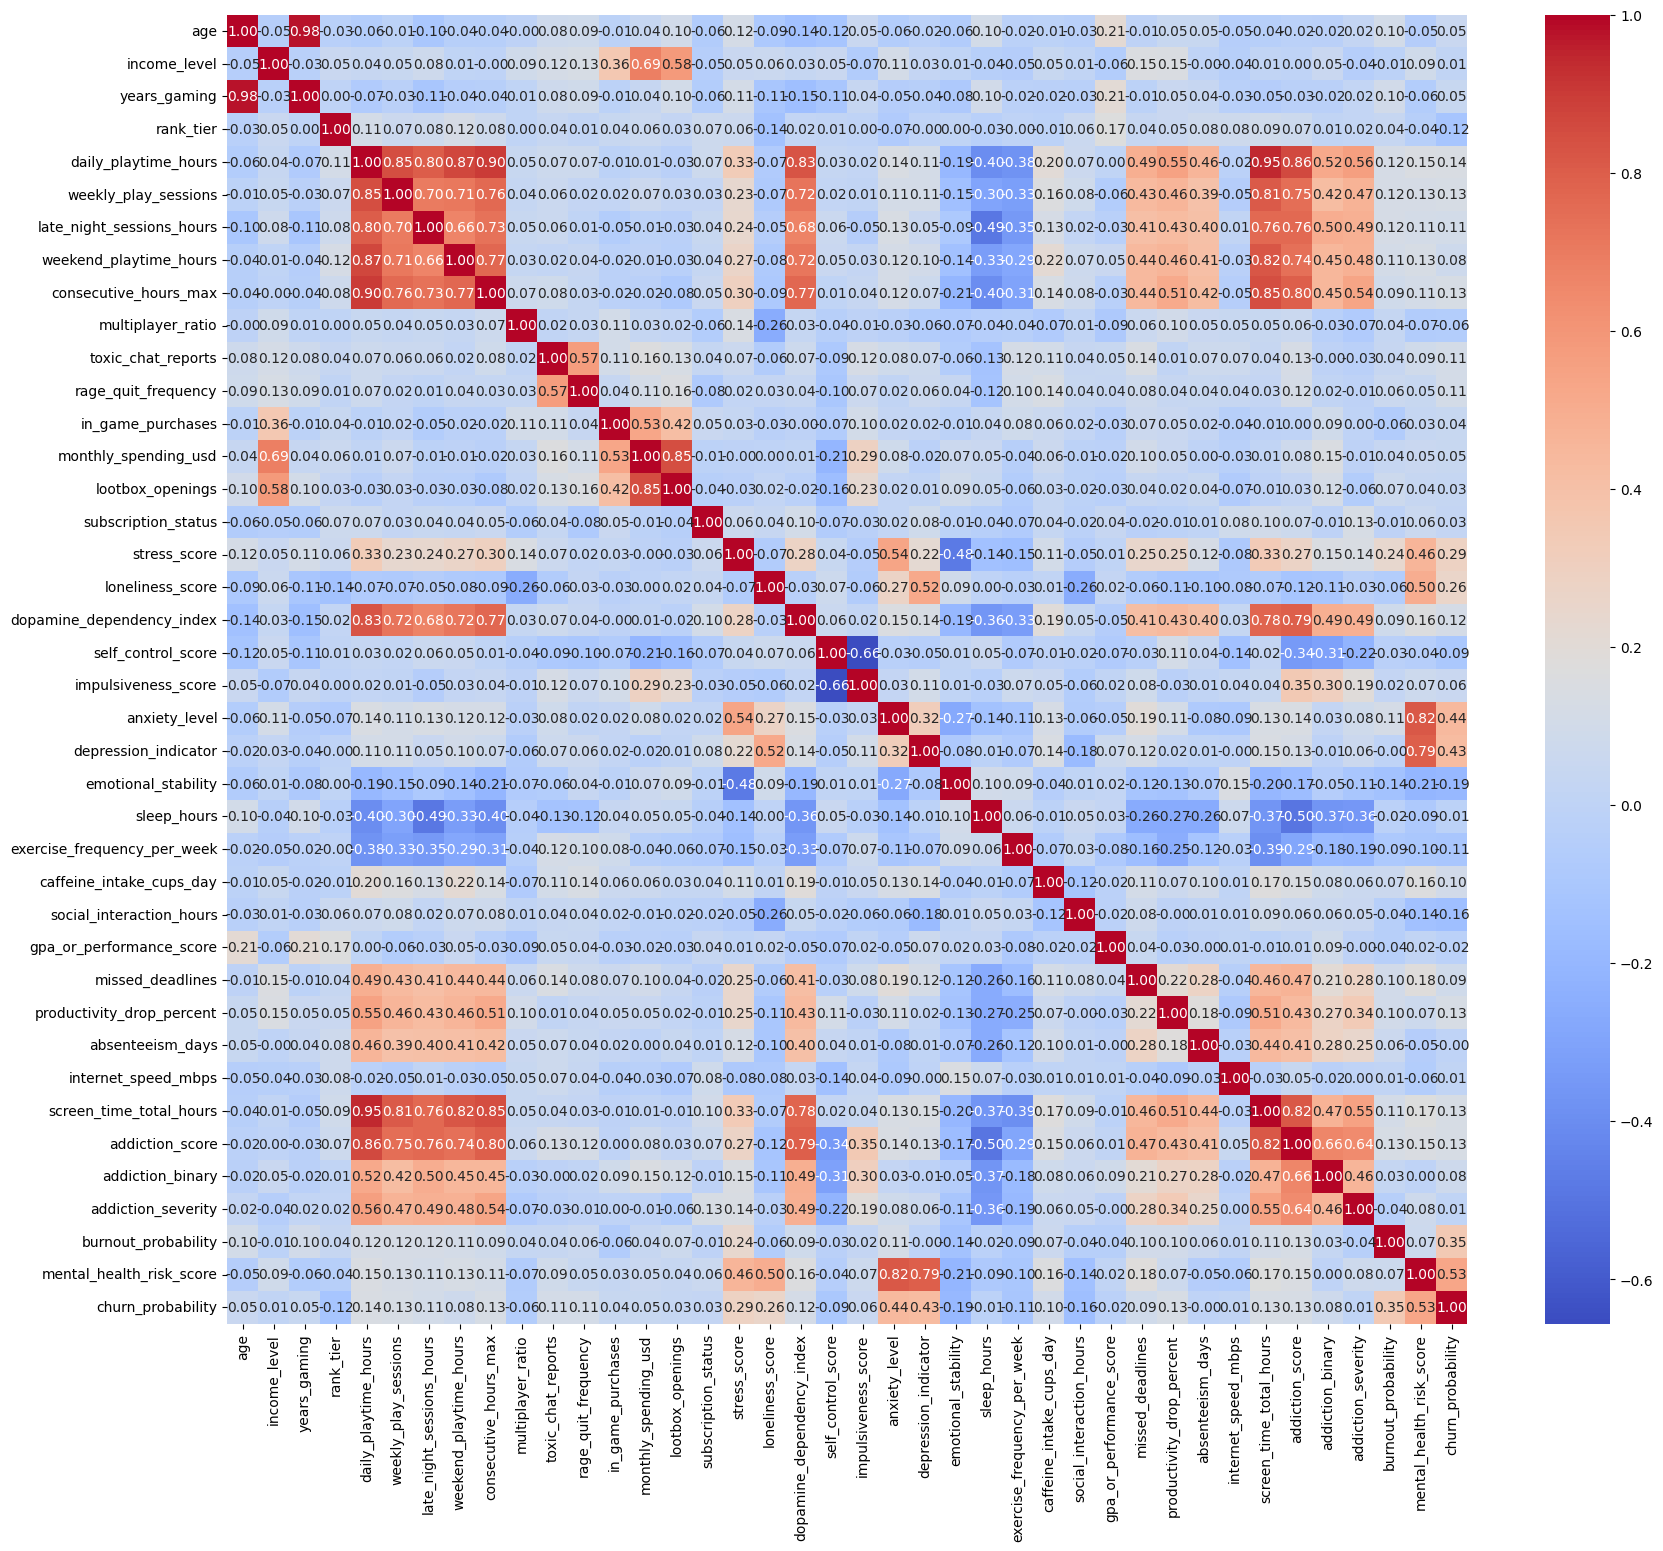

In [655]:
# Seaborn heatmap 

plt.figure(figsize=(20,17))

corr = dfe.select_dtypes(include=['number']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.show()

In [656]:
# Getting feature using the highest corelation

corr_matrix = dfe.corr().abs()

corr_pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().sort_values(ascending=False))

print("Head of corr : \n", corr_pairs.head(15))

Head of corr : 
 age                       years_gaming                 0.979611
daily_playtime_hours      screen_time_total_hours      0.945771
gpa_or_performance_score  occupation_Student           0.915510
daily_playtime_hours      consecutive_hours_max        0.900978
                          weekend_playtime_hours       0.865625
                          addiction_score              0.861188
monthly_spending_usd      lootbox_openings             0.847545
daily_playtime_hours      weekly_play_sessions         0.847174
consecutive_hours_max     screen_time_total_hours      0.846300
daily_playtime_hours      dopamine_dependency_index    0.827996
weekend_playtime_hours    screen_time_total_hours      0.822905
anxiety_level             mental_health_risk_score     0.816669
screen_time_total_hours   addiction_score              0.815875
weekly_play_sessions      screen_time_total_hours      0.808181
daily_playtime_hours      late_night_sessions_hours    0.800191
dtype: float64


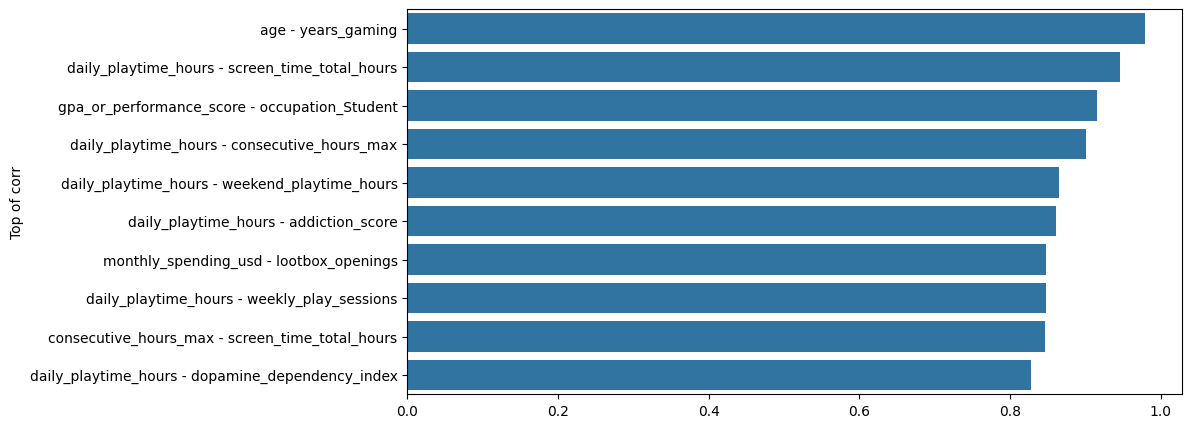

In [657]:
# Feature comparison visual data

top_corr = corr_pairs.head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_corr.values, y=[f"{a} - {b}" for a,b in top_corr.index])
plt.ylabel("Top of corr")

plt.show()


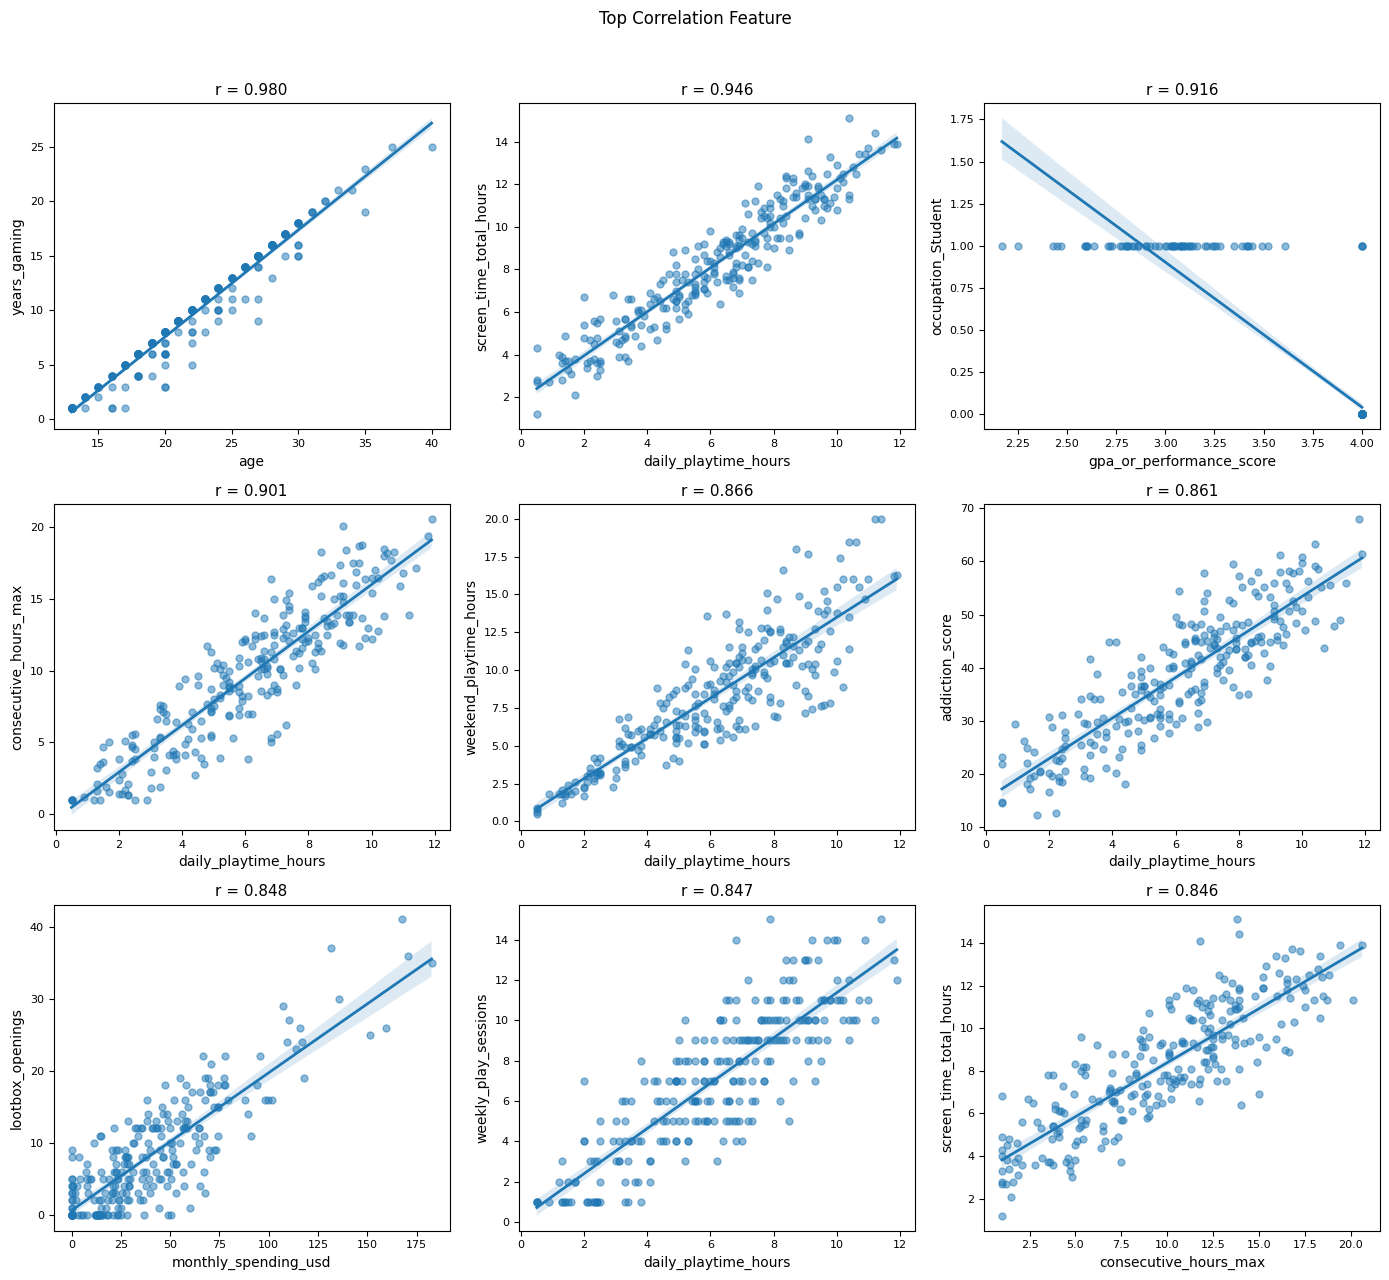

In [ ]:
# EDA for top correlation feature
# correlation coefficient — close to 1.0, the relation is more stronger

top_n = 9

pairs = corr_pairs.head(top_n)

cols_n = 3
rows_n = math.ceil(top_n / cols_n)

fig, axes = plt.subplots(ncols=cols_n, nrows=rows_n, figsize=(14,5 * 2.5))
axes = axes.flatten()

for idx, ((f1, f2), corr) in enumerate(pairs.items()):
    sns.regplot(data=dfe, x=f1, y=f2, ax=axes[idx],scatter_kws={"alpha": 0.5, "s": 25}, line_kws={"linewidth": 2})

    axes[idx].set_title(
        f"r = {corr:.3f}",
        fontsize=11
    )

    axes[idx].tick_params(
        axis='x',
        labelsize=8
    )

    axes[idx].tick_params(
        axis='y',
        labelsize=8
    )

plt.suptitle("Top Correlation Feature", y=1.02)
plt.tight_layout()
plt.show()

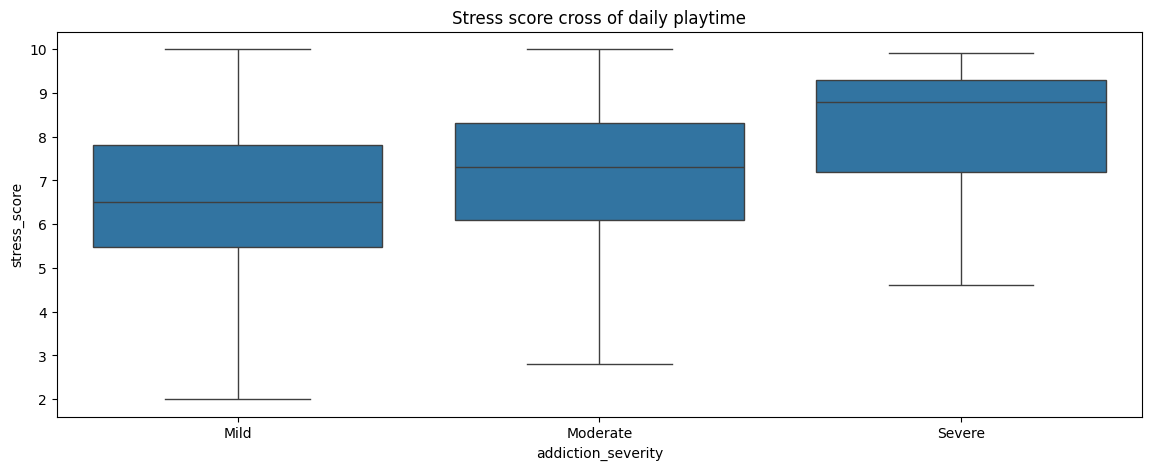

In [659]:
# Comparasion using boxplot to get visualization of stress_score and daily_time_hours

plt.figure(figsize=(14,5))

sns.boxplot(data=df, x='addiction_severity', y='stress_score')


plt.title("Stress score cross of daily playtime")
plt.show()

In [ ]:
# Prepare data for train and test

drop_cols = [
    'addiction_score',         
    'addiction_severity',       
    'addiction_binary', 
    'burnout_probability',     
    'mental_health_risk_score', 
    'churn_probability'        
]

# Remove an data leakage
X = dfe.select_dtypes(include=['number']).drop(drop_cols, axis=1)

y = dfe['addiction_binary']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

print("Label test count data")
print(y_valid.value_counts())
print("Train shape : ", X_train.shape)
print("Length of data : ",len(y_train))

Label test count data
addiction_binary
0    40
1    10
Name: count, dtype: int64
Train shape :  (200, 34)
Length of data :  200


In [661]:
# Balancing data using SMOTEK

print("Data before balancing : ", len(y_train))

smote = SMOTETomek(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Train data after balancing : ", len(y_train_smote))

Data before balancing :  200
Train data after balancing :  336


In [662]:
# Train and test using RandomForestRegression
time_start = time.perf_counter()

model_rfr = RandomForestRegressor(max_depth=10, random_state=42, min_samples_split=10, min_samples_leaf=5)

model_rfr.fit(X_train_smote, y_train_smote)

y_smote_preds = model_rfr.predict(X_valid)

mae = mean_absolute_error(y_valid, y_smote_preds)
r2 = r2_score(y_valid, y_smote_preds)

print("Time accuracy", format(time.perf_counter() - time_start, '.2f'), 'seconds')

print(f"MAE score : {mae * 100 : .2f}%")
print(f"R2 score : {r2 * 100 : .2f}%")


Time accuracy 0.11 seconds
MAE score :  16.45%
R2 score :  54.75%


In [663]:
# Train and test using RandomForestRegression
time_start = time.perf_counter()

model_xgb = XGBRegressor( 
    max_depth=5, 
    n_estimators=200, 
    learning_rate=0.4, 
    random_state=10,
    subsample=0.8,
    colsample_bytree=0.7,
    n_jobs=-1
)

model_xgb.fit(X_train_smote, y_train_smote)

y_smote_preds = model_rfr.predict(X_valid)

mae = mean_absolute_error(y_valid, y_smote_preds)
r2 = r2_score(y_valid, y_smote_preds)

print("Time accuracy", format(time.perf_counter() - time_start, '.2f'), 'seconds')

print(f"MAE score : {mae * 100 : .2f}%")
print(f"R2 score : {r2 * 100 : .2f}%")



Time accuracy 0.17 seconds
MAE score :  16.45%
R2 score :  54.75%


Text(0, 0.5, 'R2 Score')

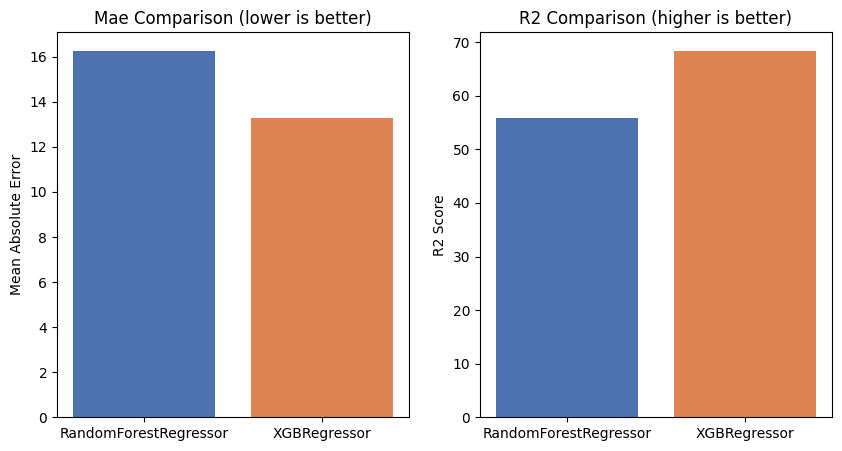

In [664]:
# Score visualization 

model = ["RandomForestRegressor", "XGBRegressor"]

mae = [16.27, 13.28]

r2 = [55.78, 68.42]

fig, axes = plt.subplots(1,2, figsize=(10,5))


axes[0].set_title("Mae Comparison (lower is better)")
axes[0].bar(model, mae, color=['#4C72B0', '#DD8452'])
axes[0].set_ylabel("Mean Absolute Error")

axes[1].set_title("R2 Comparison (higher is better)")
axes[1].bar(model, r2, color=['#4C72B0', '#DD8452'])
axes[1].set_ylabel("R2 Score")


# Classification step using :
* LogisticRegression
* XGBClassifier
* RandomForestClassifier

Time predict : 0.030475916999421315 seconds
['age', 'income_level', 'years_gaming', 'rank_tier', 'daily_playtime_hours', 'weekly_play_sessions', 'late_night_sessions_hours', 'weekend_playtime_hours', 'consecutive_hours_max', 'multiplayer_ratio', 'toxic_chat_reports', 'rage_quit_frequency', 'in_game_purchases', 'monthly_spending_usd', 'lootbox_openings', 'subscription_status', 'stress_score', 'loneliness_score', 'dopamine_dependency_index', 'self_control_score', 'impulsiveness_score', 'anxiety_level', 'depression_indicator', 'emotional_stability', 'sleep_hours', 'exercise_frequency_per_week', 'caffeine_intake_cups_day', 'social_interaction_hours', 'gpa_or_performance_score', 'missed_deadlines', 'productivity_drop_percent', 'absenteeism_days', 'internet_speed_mbps', 'screen_time_total_hours']


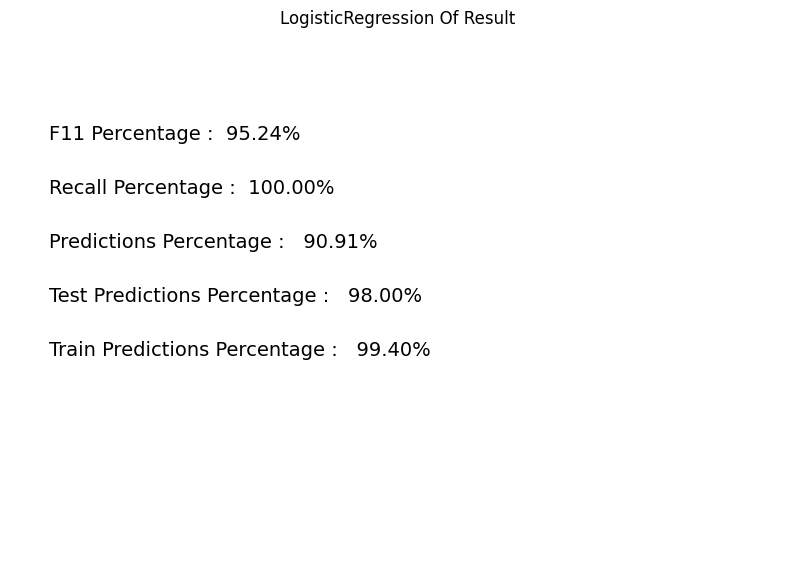

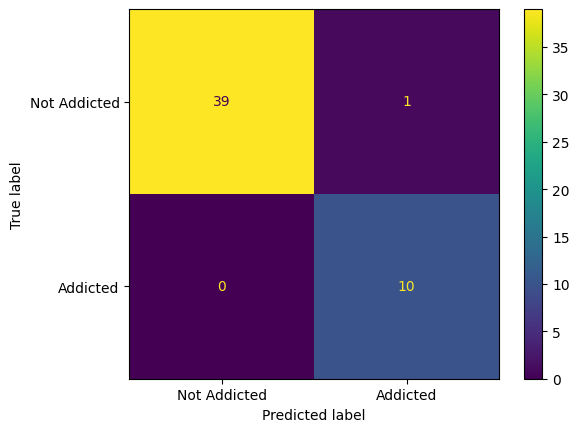

In [ ]:
# Classifier using LogisticRegression

time_start = time.perf_counter()

model_lgr = LogisticRegression(    
    max_iter=1000,
    C=0.8,
    class_weight='balanced',  
    random_state=42
    )

model_lgr.fit(X_train_smote, y_train_smote)

train_predictions = model_lgr.predict(X_train_smote)
test_predictions = model_lgr.predict(X_valid)

# Evaluate
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy = accuracy_score(y_valid, test_predictions)

Recall = recall_score(y_valid, test_predictions )
Predictions = precision_score(y_valid, test_predictions)
F11 = f1_score(y_valid, test_predictions)
cm = confusion_matrix(y_valid, test_predictions)

print(f"Time predict : {format(time.perf_counter() - time_start)} seconds")

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("LogisticRegression Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Predictions * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Addicted', 'Addicted']).plot()

plt.show()

Time predict : 0.027741750000132015 seconds
['age', 'income_level', 'years_gaming', 'rank_tier', 'daily_playtime_hours', 'weekly_play_sessions', 'late_night_sessions_hours', 'weekend_playtime_hours', 'consecutive_hours_max', 'multiplayer_ratio', 'toxic_chat_reports', 'rage_quit_frequency', 'in_game_purchases', 'monthly_spending_usd', 'lootbox_openings', 'subscription_status', 'stress_score', 'loneliness_score', 'dopamine_dependency_index', 'self_control_score', 'impulsiveness_score', 'anxiety_level', 'depression_indicator', 'emotional_stability', 'sleep_hours', 'exercise_frequency_per_week', 'caffeine_intake_cups_day', 'social_interaction_hours', 'gpa_or_performance_score', 'missed_deadlines', 'productivity_drop_percent', 'absenteeism_days', 'internet_speed_mbps', 'screen_time_total_hours']


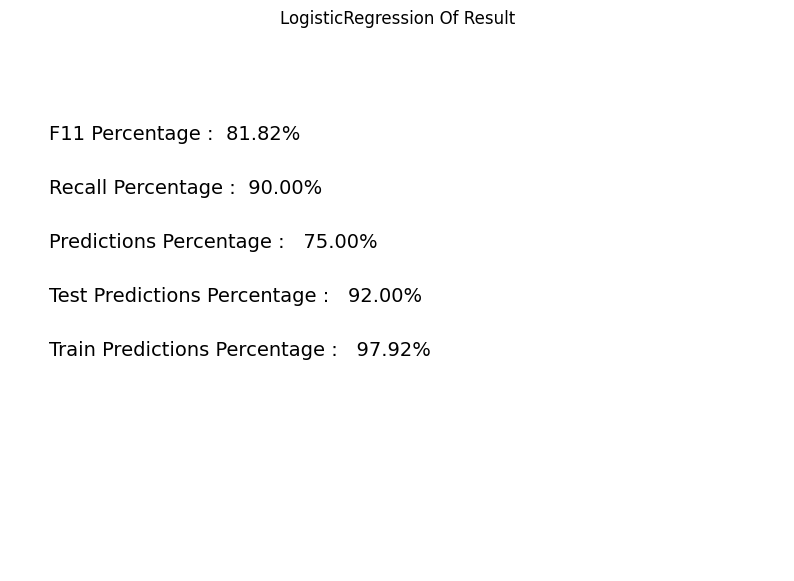

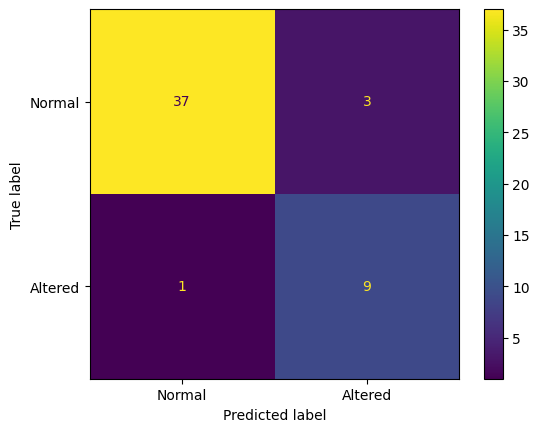

In [ ]:
# Classifier using LogisticRegression

time_start = time.perf_counter()

model_lgr = RandomForestClassifier(    
    n_estimators=50,
    max_depth=4,      
    min_samples_leaf=5,   
    max_features='sqrt',  
    random_state=42,
    class_weight='balanced'
    )

model_lgr.fit(X_train_smote, y_train_smote)

train_predictions = model_lgr.predict(X_train_smote)
test_predictions = model_lgr.predict(X_valid)

# Evaluate
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy = accuracy_score(y_valid, test_predictions)

Recall = recall_score(y_valid, test_predictions )
Predictions = precision_score(y_valid, test_predictions)
F11 = f1_score(y_valid, test_predictions)
cm = confusion_matrix(y_valid, test_predictions)

print(f"Time predict : {format(time.perf_counter() - time_start)} seconds")

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("LogisticRegression Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Predictions * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Altered']).plot()

plt.show()